# **Phase 2**
## **Setup and Data Loading**

In [1]:
# Import the libraries used throughout this notebook
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Show every column when displaying tables, and use a clean grid style for plots
pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')

# Load the raw dataset
df = pd.read_csv('https://raw.githubusercontent.com/happy-880/IT326-Project-/refs/heads/main/Dataset/Raw_dataset.csv', sep=';')

# Remove hidden spaces and tab characters from the column names
df.columns = df.columns.str.strip()

# Attributes that hold real measurements (grades, counts, rates)
numeric_cols = [
    'Previous qualification (grade)', 'Admission grade', 'Age at enrollment',
    'Curricular units 1st sem (credited)', 'Curricular units 1st sem (enrolled)',
    'Curricular units 1st sem (evaluations)', 'Curricular units 1st sem (approved)',
    'Curricular units 1st sem (grade)', 'Curricular units 1st sem (without evaluations)',
    'Curricular units 2nd sem (credited)', 'Curricular units 2nd sem (enrolled)',
    'Curricular units 2nd sem (evaluations)', 'Curricular units 2nd sem (approved)',
    'Curricular units 2nd sem (grade)', 'Curricular units 2nd sem (without evaluations)',
    'Unemployment rate', 'Inflation rate', 'GDP'
]

# Every other attribute (except the class label) is a category code
categorical_cols = [c for c in df.columns if c not in numeric_cols and c != 'Target']

print('Numeric:', len(numeric_cols))
print('Categorical:', len(categorical_cols))

Numeric: 18
Categorical: 18


## **1. Data Analysis**

### **1.1 Statistical Analysis**

The following table shows numeric attributes for the five-number summary, statistical summaries, outliers, and boxplots

In this part, we calculate the five-number summary and statistical summaries for the numeric attributes, count the outliers in each attribute using the IQR method, and draw boxplots that compare the three classes.


In [2]:
# Five-number summary and statistical summaries for the numeric attributes
df[numeric_cols].describe()

,Previous qualification (grade),Admission grade,Age at enrollment,Curricular units 1st sem (credited),Curricular units 1st sem (enrolled),Curricular units 1st sem (evaluations),Curricular units 1st sem (approved),Curricular units 1st sem (grade),Curricular units 1st sem (without evaluations),Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP
count,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000
mean,132.613314,126.978119,23.265145,0.709991,6.270570,8.299051,4.706600,10.640822,0.137658,0.541817,6.232143,8.063291,4.435805,10.230206,0.150316,11.566139,1.228029,0.001969
std,13.188332,14.482001,7.587816,2.360507,2.480178,4.179106,3.094238,4.843663,0.690880,1.918546,2.195951,3.947951,3.014764,5.210808,0.753774,2.663850,1.382711,2.269935
min,95.000000,95.000000,17.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,7.600000,-0.800000,-4.060000
25%,125.000000,117.900000,19.000000,0.000000,5.000000,6.000000,3.000000,11.000000,0.000000,0.000000,5.000000,6.000000,2.000000,10.750000,0.000000,9.400000,0.300000,-1.700000
50%,133.100000,126.100000,20.000000,0.000000,6.000000,8.000000,5.000000,12.285714,0.000000,0.000000,6.000000,8.000000,5.000000,12.200000,0.000000,11.100000,1.400000,0.320000
75%,140.000000,134.800000,25.000000,0.000000,7.000000,10.000000,6.000000,13.400000,0.000000,0.000000,7.000000,10.000000,6.000000,13.333333,0.000000,13.900000,2.600000,1.790000
max,190.000000,190.000000,70.000000,20.000000,26.000000,45.000000,26.000000,18.875000,12.000000,19.000000,23.000000,33.000000,20.000000,18.571429,12.000000,16.200000,3.700000,3.510000


This table summarizes each numeric attribute using its minimum, quartiles, maximum, mean, and standard deviation.

All attributes have 4,424 values, so nothing is missing. Most attributes have a mean close to their median, but a few don't. `Age at enrollment` has a mean higher than its median because of a small number of older students, up to age 70. The grade columns have a mean lower than their median because some students have a grade of 0. Several columns, such as `credited` and `without evaluations`, are 0 for most students. The attributes are also on very different scales, from small unit counts to grades up to 190.


In [3]:
# Count outliers using the IQR method, the same rule the boxplots use
# (values more than 1.5 x IQR below Q1 or above Q3)
for col in numeric_cols:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    outliers = df[(df[col] < q1 - 1.5 * iqr) | (df[col] > q3 + 1.5 * iqr)]
    print(f"{col}: {len(outliers)} outliers")

Previous qualification (grade): 179 outliers
Admission grade: 86 outliers
Age at enrollment: 441 outliers
Curricular units 1st sem (credited): 577 outliers
Curricular units 1st sem (enrolled): 424 outliers
Curricular units 1st sem (evaluations): 158 outliers
Curricular units 1st sem (approved): 180 outliers
Curricular units 1st sem (grade): 726 outliers
Curricular units 1st sem (without evaluations): 294 outliers
Curricular units 2nd sem (credited): 530 outliers
Curricular units 2nd sem (enrolled): 369 outliers
Curricular units 2nd sem (evaluations): 109 outliers
Curricular units 2nd sem (approved): 44 outliers
Curricular units 2nd sem (grade): 877 outliers
Curricular units 2nd sem (without evaluations): 282 outliers
Unemployment rate: 0 outliers
Inflation rate: 0 outliers
GDP: 0 outliers


This step counts the outliers in each numeric attribute using the IQR method, the same rule the boxplots use. A value is an outlier if it falls more than 1.5 × IQR below Q1 or above Q3.

Most attributes have outliers, but the numbers vary a lot. The grade columns have the most, with 726 in the 1st semester and 877 in the 2nd. The `credited` columns also have many (577 and 530), along with `Age at enrollment` (441) and the `enrolled` columns (424 and 369). In contrast, `Unemployment rate`, `Inflation rate`, and `GDP` have no outliers at all.

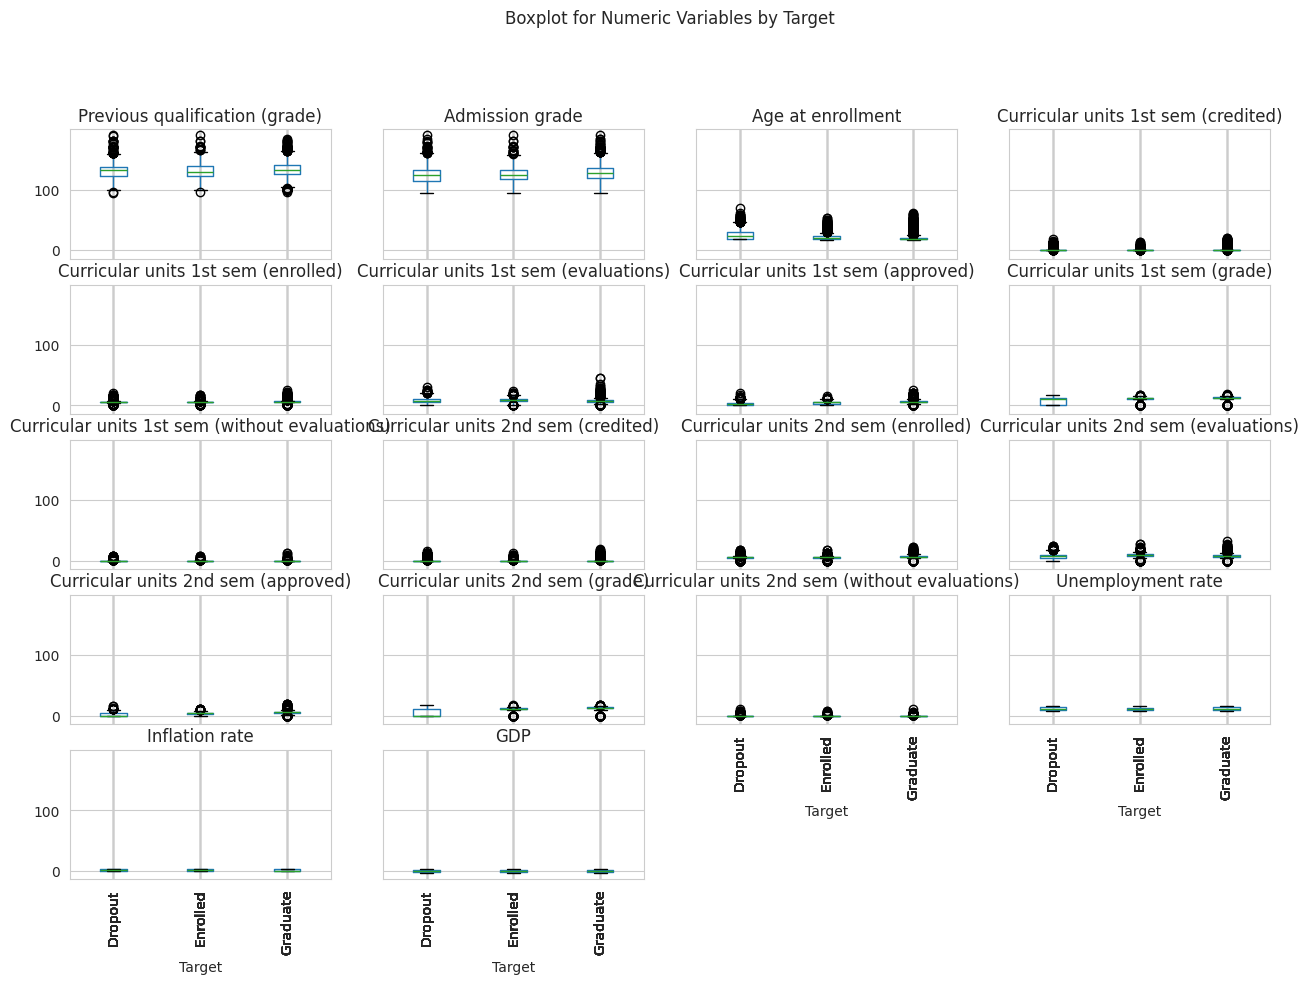

In [4]:
# Boxplots of the numeric attributes, split by class label
df.boxplot(column=numeric_cols, by='Target', figsize=(15, 10), rot=90)
plt.suptitle('Boxplot for Numeric Variables by Target', y=1.02)
plt.show()

These boxplots show each numeric attribute split by the class label (Dropout, Enrolled, Graduate), so we can compare the three groups side by side.

For `Previous qualification (grade)` and `Admission grade`, the three boxes look very similar, so these attributes don't clearly separate the groups. `Age at enrollment` is different: the Dropout box sits higher and is wider than the other two, meaning dropouts tend to be older.

The grade columns show the clearest difference. In both semesters, the Dropout box stretches down toward 0, while the Enrolled and Graduate boxes stay narrow and higher, with only a few outliers at 0. The economic attributes (`Unemployment rate`, `Inflation rate`, and `GDP`) look almost identical across all three groups.

Because all plots share the same y-axis, attributes with small values, such as the unit counts, appear squashed near 0 and are hard to read.

**How this informed preprocessing:**

The outliers were not removed. Most represent real students, such as older students who enrolled later in life or students who failed their courses, so removing them would discard genuine and predictive information. The large number of zero-grade outliers is examined in Section 1.2 and handled in Section 2.2.

### **1.2 Data Visualization**


#### **Missing Values Analysis**
In this part, we check the dataset for missing values using `isnull()`. We then examine the semester grade columns more closely, since a value of 0.00 may hide missing information. To test this, we select the students with a zero grade and compare how they are distributed across the class label with the dataset as a whole, and check how many evaluations they sat.


In [5]:
# Missing values check
print("Total missing values:", df.isnull().sum().sum())

# Zero-grade records
zeros_1 = df[df['Curricular units 1st sem (grade)'] == 0]
zeros_2 = df[df['Curricular units 2nd sem (grade)'] == 0]
print(f"\n1st sem zero grades: {len(zeros_1)}")
print(f"2nd sem zero grades: {len(zeros_2)}")

# How they distribute across the class label
print("\n1st sem zero-grade by Target:")
print(zeros_1['Target'].value_counts())
print("\n2nd sem zero-grade by Target:")
print(zeros_2['Target'].value_counts())
print("\nOverall Target distribution:")
print(df['Target'].value_counts())

# Verifying what the zeros mean
print("\nCourses approved (1st sem zero-grade students):")
print(zeros_1['Curricular units 1st sem (approved)'].value_counts())
print("\nEvaluations sat (1st sem zero-grade students):")
print(zeros_1['Curricular units 1st sem (evaluations)'].describe())

print("\nCourses approved (2nd sem zero-grade students):")
print(zeros_2['Curricular units 2nd sem (approved)'].value_counts())
print("\nEvaluations sat (2nd sem zero-grade students):")
print(zeros_2['Curricular units 2nd sem (evaluations)'].describe())

Total missing values: 0

1st sem zero grades: 718
2nd sem zero grades: 870

1st sem zero-grade by Target:
Target
Dropout     570
Graduate     77
Enrolled     71
Name: count, dtype: int64

2nd sem zero-grade by Target:
Target
Dropout     727
Graduate     75
Enrolled     68
Name: count, dtype: int64

Overall Target distribution:
Target
Graduate    2209
Dropout     1421
Enrolled     794
Name: count, dtype: int64

Courses approved (1st sem zero-grade students):
Curricular units 1st sem (approved)
0    718
Name: count, dtype: int64

Evaluations sat (1st sem zero-grade students):
count    718.000000
mean       3.820334
std        4.378823
min        0.000000
25%        0.000000
50%        2.500000
75%        7.000000
max       21.000000
Name: Curricular units 1st sem (evaluations), dtype: float64

Courses approved (2nd sem zero-grade students):
Curricular units 2nd sem (approved)
0    870
Name: count, dtype: int64

Evaluations sat (2nd sem zero-grade students):
count    870.000000
mean      

A check for null values across all 37 columns returned zero, meaning there are no conventionally missing values in the dataset.

The grade columns tell a different story. `Curricular units 1st sem (grade)` holds the value 0.00 for 718 students, and `Curricular units 2nd sem (grade)` holds it for 870. In Portugal, university grades run from 0 to 20, so a grade of zero is a legitimate value. A cell containing 0.00 is not empty, and no null check will flag it as missing.

To determine whether these values were meaningful or erroneous, we examined how they distribute across the class label:

| | Dropout | Graduate | Enrolled | % Dropout |
|---|---|---|---|---|
| 1st sem zero-grade (718) | 570 | 77 | 71 | 79% |
| 2nd sem zero-grade (870) | 727 | 75 | 68 | 84% |
| Full dataset (4,424) | 1,421 | 2,209 | 794 | 32% |

Only 32% of students in the dataset dropped out overall, but among students with a zero first-semester grade, 79% dropped out, rising to 84% in the second semester. This is about two and a half times the overall dropout rate. The number of affected students grows from 718 to 870.

So 0.00 is actually carrying information. In both semesters, every student with a 0.00 grade passed zero curricular units. The number of evaluations they sat varies considerably: at least a quarter sat none at all, while the median is 2.5 in the first semester and 5 in the second, and individual students sat as many as 21. The group therefore contains two distinct situations : students who never engaged, and students who were assessed but passed nothing.

The column records both situations as 0.00, so a student who received a zero and a student who was never assessed look the same in the statistics. This pulls the mean down and stretches the boxplot whiskers toward a floor where 16% of first-semester records sit.

Section 2 addresses how these records are treated.

#### **Class Label Distribution**
In this part, we count how many students belong to each class using `value_counts()` and display the result as a bar chart, with the exact count shown above each bar. We also calculate the percentage of each class, to see whether the dataset is balanced.


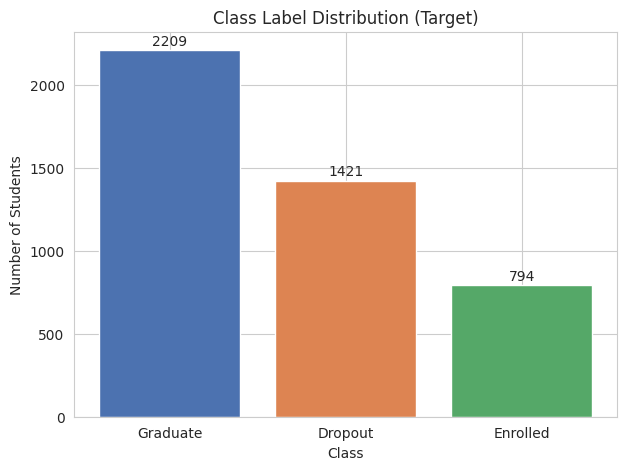


 Target
Graduate    49.93
Dropout     32.12
Enrolled    17.95
Name: proportion, dtype: float64


In [6]:
# Count how many students belong to each class
counts = df['Target'].value_counts()

# Bar chart of the class label distribution
plt.figure(figsize=(7, 5))
bars = plt.bar(counts.index, counts.values, color=['#4C72B0', '#DD8452', '#55A868'])
plt.title('Class Label Distribution (Target)')
plt.xlabel('Class')
plt.ylabel('Number of Students')

# Write the count on top of each bar so the values are easy to read
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 30, int(height), ha='center')

plt.show()

# Percentage of students in each class
print("\n", df['Target'].value_counts(normalize=True).round(4) * 100)

The class attribute `Target` has three values, distributed unevenly across the 4,424 records. Graduate accounts for 49.93% of students (2,209), Dropout for 32.12% (1,421), and Enrolled for 17.95% (794).

The dataset is therefore imbalanced, though not severely. The majority class holds roughly half the records and the smallest class under a fifth.

This has a direct consequence for evaluation. A classifier that predicted Graduate for every student would score 49.93% accuracy while being useless, so accuracy alone cannot demonstrate that a model has learned anything. Per-class metrics are needed to show whether the minority classes are being identified at all.

The imbalance also matters for interpretation. Enrolled is both the smallest class and the least clearly defined, because it describes students still studying beyond the normal course duration, which sits between the other two outcomes rather than opposing them. Villar and de Andrade (2024) report F1 scores of 0.69 for the Enrolled class using a decision tree, compared with 0.75 for Graduate and 0.78 for Dropout. Enrolled scores lowest in every algorithm they tested.

#### **Distribution of Numeric Attributes**
In this part, we plot histograms for six numeric attributes, chosen because each shows a different distribution shape. The histograms are arranged in a 2 by 3 grid, and each one divides the attribute's range into 30 intervals to show where the values are concentrated.


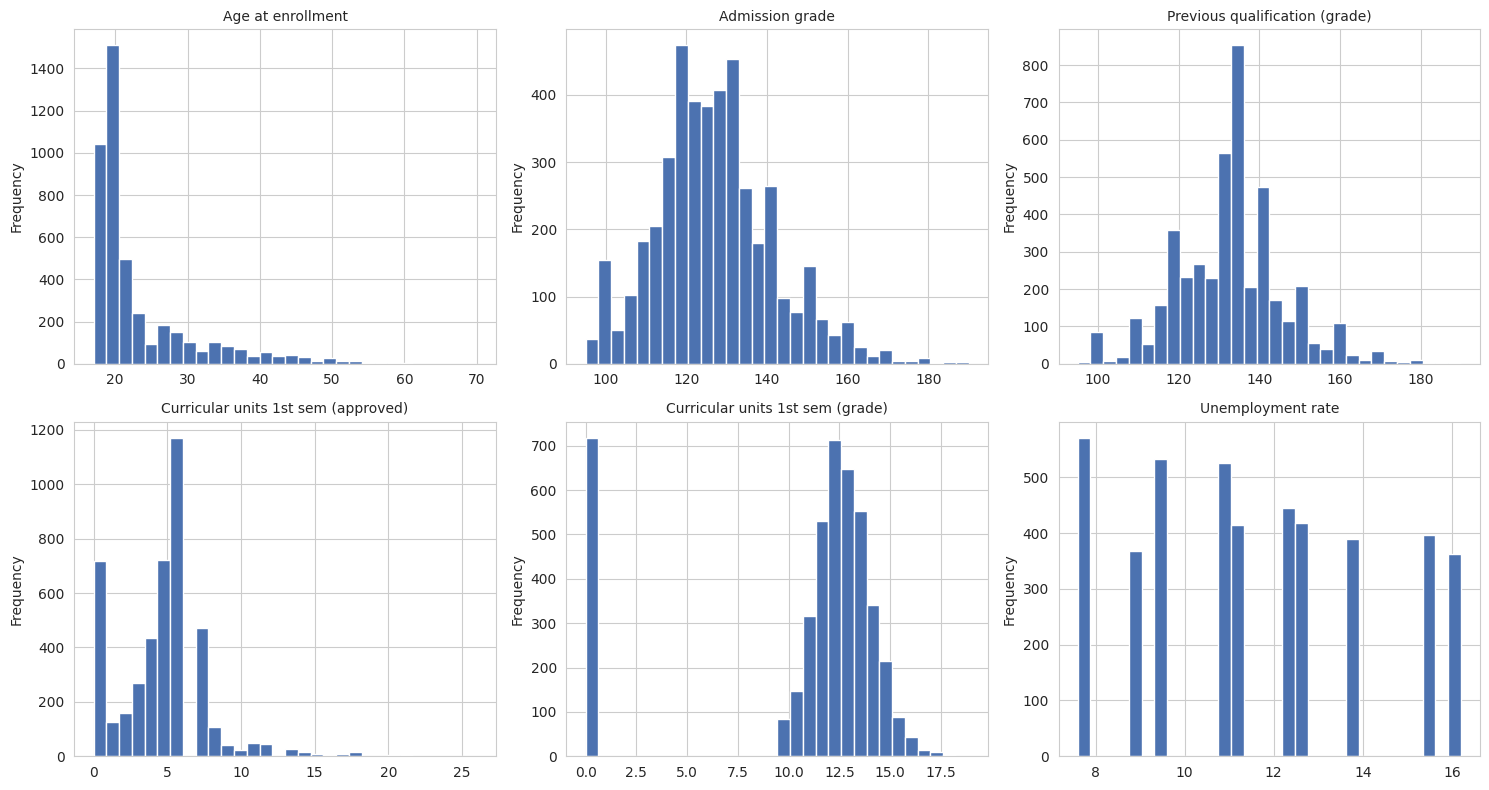

In [7]:
# Six numeric attributes chosen because each shows a different distribution shape
key_numeric = [
    'Age at enrollment',
    'Admission grade',
    'Previous qualification (grade)',
    'Curricular units 1st sem (approved)',
    'Curricular units 1st sem (grade)',
    'Unemployment rate'
]

# Create a 2x3 grid of plots and flatten it so we can loop over it easily
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

# Draw one histogram per attribute
for i, col in enumerate(key_numeric):
    axes[i].hist(df[col], bins=30, color='#4C72B0', edgecolor='white')
    axes[i].set_title(col, fontsize=10)
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

`Age at enrollment` is heavily right-skewed. Most students enrol between 18 and 20, with frequency dropping sharply after that and a long thin tail extending to 70. The range is wide but the values are concentrated at one end, which makes the raw column difficult to interpret and a candidate for discretization into age bands.

`Admission grade` is approximately normal, centred around 125 and ranging from roughly 95 to 190. `Previous qualification (grade)` follows a similar shape but is visibly spikier, with certain values far more frequent than their neighbours, which is consistent with grades being rounded before conversion to the 0–200 admission scale.

`Curricular units 1st sem (approved)` shows a spike of 718 students at zero, separate from a hump centred around 5 to 6 courses. `Curricular units 1st sem (grade)` shows the same pattern more starkly: a tall isolated bar at 0.00, then an empty gap, then a normal distribution beginning at 10. No student holds a grade between 0 and 10. This gap confirms that the zero values do not belong to the same distribution as the rest of the column, supporting the finding in the missing values analysis above.

`Unemployment rate` does not behave like a continuous variable. Its histogram shows ten evenly spaced bars with empty space between them, because the attribute records a national annual figure shared by every student who enrolled in the same year. The same applies to `Inflation rate` and `GDP`. These three attributes describe the national economy in the year of enrollment rather than the individual student, so all students from the same year share identical values. They effectively act as a label for enrollment year.

These distributions point to two preprocessing needs. The attributes operate on very different scales: admission grades run from 0 to 200, semester grades from 0 to 20, age from 17 to 70, and unemployment from 7 to 16. These differences will distort any distance-based method unless normalized. The skew in `Age at enrollment` also makes it a candidate for discretization.

#### **Distribution of Categorical Attributes**
In this part, we plot bar charts for six categorical attributes, ranging from binary attributes to ones with many categories. For each attribute, we show the ten most common categories, so the charts remain readable even for attributes with many codes.


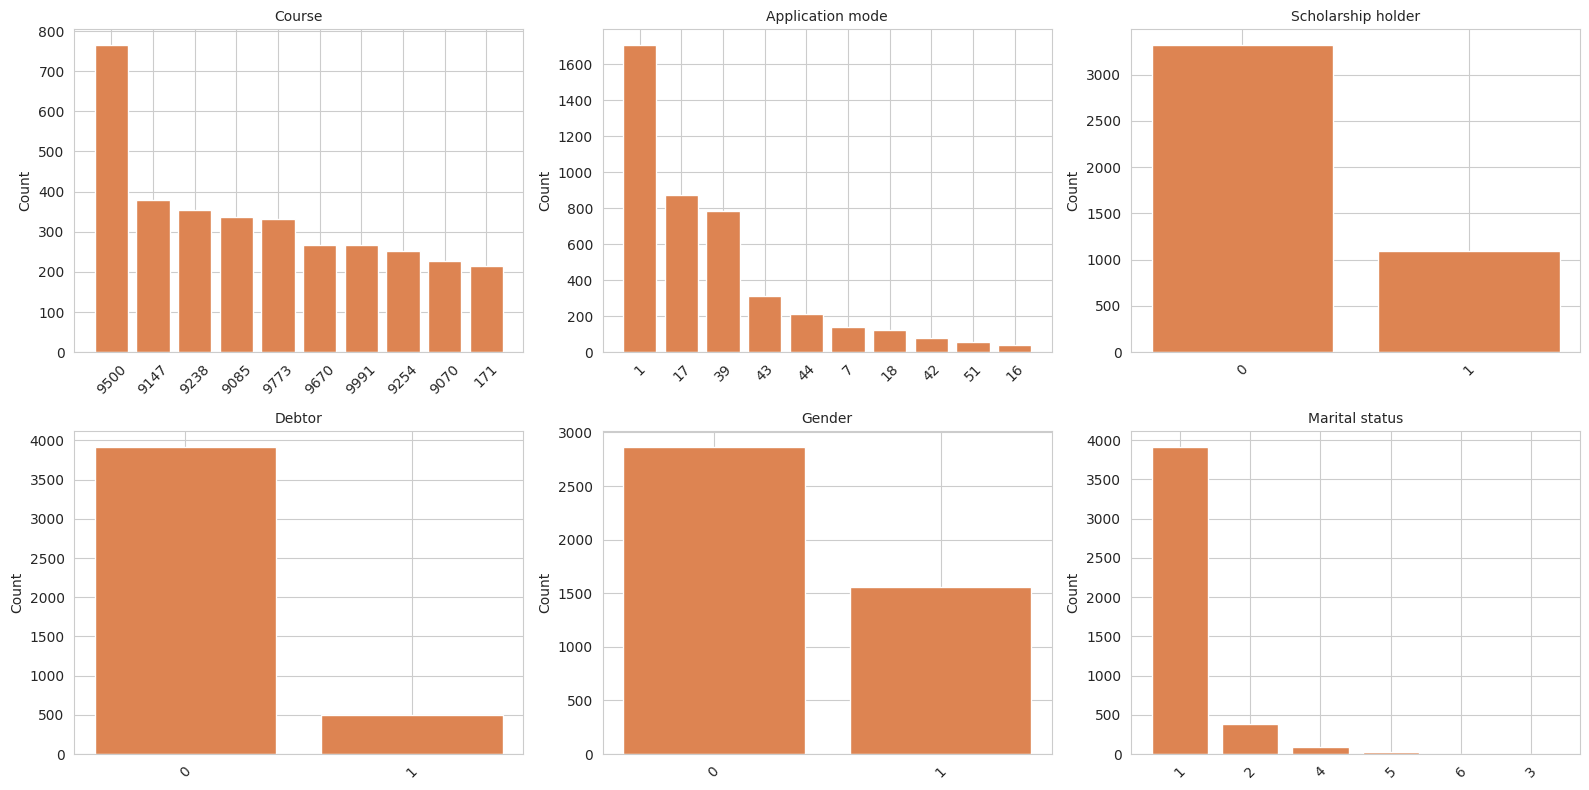

In [8]:
# Six categorical attributes, ranging from binary (2 values) to many categories
cat_to_plot = ['Course', 'Application mode', 'Scholarship holder', 'Debtor', 'Gender', 'Marital status']

# Create a 2x3 grid of plots and flatten it so we can loop over it easily
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()

# Draw one bar chart per attribute, showing at most the 10 most common categories
for i, col in enumerate(cat_to_plot):
    counts = df[col].value_counts().head(10)
    axes[i].bar(counts.index.astype(str), counts.values, color='#DD8452')
    axes[i].set_title(col, fontsize=10)
    axes[i].set_ylabel('Count')
    axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

Six categorical attributes were plotted as bar charts. All are stored as integers in the raw file, but the integers are category codes rather than measurements: `Course` 9254 is not larger than `Course` 171, it is simply a different course.

The attributes differ considerably in cardinality. `Gender`, `Scholarship holder` and `Debtor` are binary. `Marital status` has six categories, while `Course` has 17 and `Application mode` has 18. Other attributes contain many more categories: `Father's occupation` has 46 distinct codes and `Mother's qualification` has 29.

The distributions are uneven. `Debtor` and `Marital status` are heavily one-sided: around 3,900 students have no outstanding fees, and a similar number are single. `Application mode` is sharply skewed, with roughly 1,700 students entering through a single route and the least common routes holding fewer than 50. `Course` is more balanced, with one dominant course of around 765 students and the rest spread between roughly 215 and 380. Several `Marital status` categories contain very few students, which means encoding them will produce columns that are almost entirely zeros.

This has a direct consequence for preprocessing. Leaving these attributes as integers would imply an ordering that does not exist, and would allow two unrelated courses to be treated as similar simply because their codes are numerically close. Encoding is therefore required before clustering. Attributes with many categories are harder to encode, since `Father's occupation` alone would expand the dataset considerably.

#### **Relationship Between Attributes**
In this part, we use three scatter plots to examine relationships between pairs of numeric attributes. In the first plot, each class is shown in a different colour, so we can see how the classes separate. The points are made semi-transparent, so areas where many students overlap appear darker.


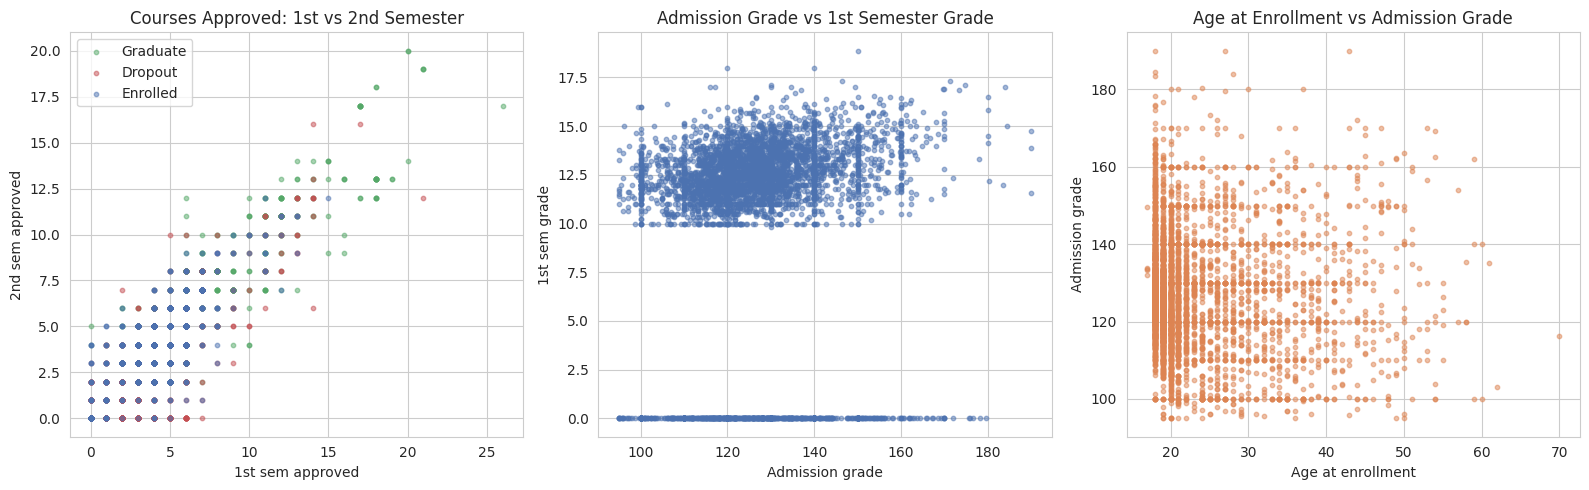

In [9]:
# Three scatter plots side by side
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# One colour per class, so the first plot can show how the classes are spread
colors = {'Graduate': '#55A868', 'Dropout': '#C44E52', 'Enrolled': '#4C72B0'}

# Plot 1: courses approved in the 1st semester vs the 2nd, coloured by class
for label, color in colors.items():
    subset = df[df['Target'] == label]
    axes[0].scatter(subset['Curricular units 1st sem (approved)'],
                    subset['Curricular units 2nd sem (approved)'],
                    alpha=0.5, s=10, color=color, label=label)
axes[0].set_xlabel('1st sem approved')
axes[0].set_ylabel('2nd sem approved')
axes[0].set_title('Courses Approved: 1st vs 2nd Semester')
axes[0].legend()

# Plot 2: admission grade vs 1st semester grade
axes[1].scatter(df['Admission grade'], df['Curricular units 1st sem (grade)'],
                alpha=0.5, s=10, color='#4C72B0')
axes[1].set_xlabel('Admission grade')
axes[1].set_ylabel('1st sem grade')
axes[1].set_title('Admission Grade vs 1st Semester Grade')

# Plot 3: age at enrollment vs admission grade
axes[2].scatter(df['Age at enrollment'], df['Admission grade'],
                alpha=0.5, s=10, color='#DD8452')
axes[2].set_xlabel('Age at enrollment')
axes[2].set_ylabel('Admission grade')
axes[2].set_title('Age at Enrollment vs Admission Grade')

plt.tight_layout()
plt.show()

Three scatter plots were produced to examine relationships between numeric attributes.

1. The first plot compares courses approved in the first semester against the second, coloured by class label. The points form a broad diagonal band, indicating that the two attributes are strongly related: students who pass few courses in the first semester generally pass few in the second. The class labels separate visibly along this band, with Dropout concentrated near the origin and Graduate extending toward the upper right, while Enrolled sits across the middle. Because the two attributes carry similar information, they are partially redundant, which is relevant when selecting features.

2. The second plot compares admission grade against first semester grade. The main cloud of points sits between 10 and 18 on the vertical axis with a hard floor at 10, and no student appears between 0 and 10. Separated from this cloud is a horizontal band of points lying flat at 0.00. These points spread across the entire admission grade range, from roughly 95 to 180. Students admitted with high grades appear in this band alongside students admitted with low ones, which indicates that a zero grade is not a measure of academic ability. This supports the earlier conclusion that 0.00 records a different situation rather than a low result.

3. The third plot compares age at enrollment against admission grade. The points form vertical stripes because age is recorded in whole years, and they cluster densely between 17 and 25 before thinning toward 70. No relationship is visible between the two attributes: older students span the same admission grade range as younger ones. The vertical striping also confirms that age, although stored as a continuous value, takes a limited number of discrete values and is a reasonable candidate for discretization.

## **2. Data Preprocessing**

### **2.1 Preprocessing Technique 1: Discretization**

**Why Discretization?**

The distribution of `Age at enrollment` is highly right-skewed, with most students concentrated at younger ages and a long tail extending to older ages. Therefore, discretization is applied to transform the continuous age values into meaningful age groups.

**Target Attributes:** `Age at enrollment`

**Technique Applied:** Discretization into six age groups


In [10]:
# Work on a copy so the raw dataset stays unchanged
df_preprocessed = df.copy()

df_preprocessed.head()

,Marital status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,Mother's occupation,Father's occupation,Admission grade,Displaced,Educational special needs,Debtor,Tuition fees up to date,Gender,Scholarship holder,Age at enrollment,International,Curricular units 1st sem (credited),Curricular units 1st sem (enrolled),Curricular units 1st sem (evaluations),Curricular units 1st sem (approved),Curricular units 1st sem (grade),Curricular units 1st sem (without evaluations),Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,1,17,5,171,1,1,122.0,1,19,12,5,9,127.3,1,0,0,1,1,0,20,0,0,0,0,0,0.000000,0,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254,1,1,160.0,1,1,3,3,3,142.5,1,0,0,0,1,0,19,0,0,6,6,6,14.000000,0,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070,1,1,122.0,1,37,37,9,9,124.8,1,0,0,0,1,0,19,0,0,6,0,0,0.000000,0,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,17,2,9773,1,1,122.0,1,38,37,5,3,119.6,1,0,0,1,0,0,20,0,0,6,8,6,13.428571,0,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,39,1,8014,0,1,100.0,1,37,38,9,9,141.5,0,0,0,1,0,0,45,0,0,6,9,5,12.333333,0,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate


#### **Preparing the Dataset for Preprocessing**

A copy of the original dataset was created before applying any preprocessing technique. This was done to keep the raw dataset unchanged, as required for the project.

The copied dataset is stored in `df_preprocessed`, which will be used for all preprocessing operations. The `head()` function is then used to display the first five records and verify that the copied dataset was loaded correctly.

In [11]:
# Group the continuous age values into six age bands
df_preprocessed['Age Group'] = pd.cut(
    df_preprocessed['Age at enrollment'],
    bins=[16, 20, 25, 30, 40, 50, 70],
    labels=['17-20', '21-25', '26-30', '31-40', '41-50', '51-70']
)

# Compare the original age with its new age group
df_preprocessed[['Age at enrollment', 'Age Group']].head(10)

,Age at enrollment,Age Group
0,20,17-20
1,19,17-20
2,19,17-20
3,20,17-20
4,45,41-50
5,50,41-50
6,18,17-20
7,22,21-25
8,21,21-25
9,18,17-20


#### **Applying Discretization**

The `pd.cut()` function was used to divide the continuous `Age at enrollment` values into six predefined age intervals. The intervals were selected to represent meaningful age ranges within the dataset.

The `bins` parameter defines the boundaries of these intervals, while the `labels` parameter assigns a readable category to each interval. A new attribute called `Age Group` was created to store the resulting categories.

The second part of the code displays the original `Age at enrollment` together with the new `Age Group` attribute. This allows us to verify that each student's numerical age was correctly assigned to the appropriate age category.

The output confirms that the transformation was successfully applied. For instance, students with ages such as 18, 19, and 20 are assigned to the `17-20` group, while students with ages such as 21 and 22 are assigned to the `21-25` group.

In [12]:
# Check that every student was placed into an age group
print("Missing values in Age Group:", df_preprocessed['Age Group'].isna().sum())

# Number of students in each age group
print("\nAge Group distribution:")
print(df_preprocessed['Age Group'].value_counts().sort_index())

Missing values in Age Group: 0

Age Group distribution:
Age Group
17-20    2551
21-25     828
26-30     383
31-40     437
41-50     182
51-70      43
Name: count, dtype: int64


#### **Checking the Result of Discretization**

After creating the `Age Group` attribute, the resulting column was checked for missing values to make sure that all students were successfully assigned to an age group.

The distribution of the new age groups was also calculated to determine how many students belong to each category.

The result showed that there were no missing values in `Age Group`, which means that all students were successfully assigned to one of the six predefined age groups. Most students belong to the 17-20 age group, while the older age groups generally contain fewer students, although the distribution varies slightly between some groups.

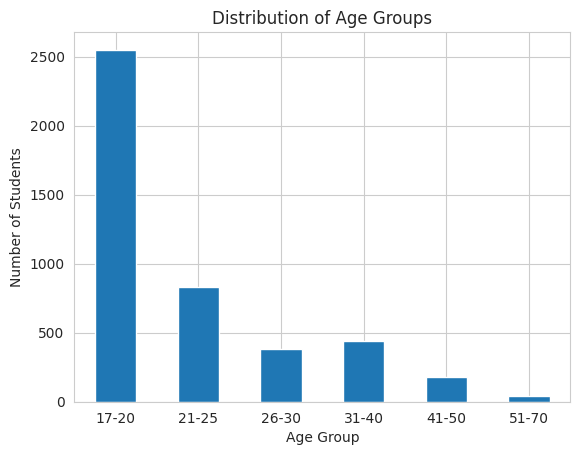

In [13]:
# Bar chart of the number of students in each age group
df_preprocessed['Age Group'].value_counts().sort_index().plot(kind='bar')

plt.xlabel('Age Group')
plt.ylabel('Number of Students')
plt.title('Distribution of Age Groups')
plt.xticks(rotation=0)
plt.show()

#### **Visualizing the Age Groups**

This code creates a bar chart to visualize the number of students in each age group after applying discretization.

The `value_counts()` function counts the number of students in each age group, while `sort_index()` arranges the groups in their predefined age order. The `plot(kind='bar')` function then displays these counts as a bar chart.

The x-axis represents the age groups, and the y-axis represents the number of students in each group. The chart shows that the `17-20` age group contains the largest number of students, while the `51-70` age group contains the smallest number.

This result is consistent with the distribution observed in the data analysis, where most students were concentrated at younger ages.

In [14]:
# Show the original and discretized age values for comparison

print("--- Before Discretization ---")
display(df[['Age at enrollment']].head(10))

print("\n--- After Discretization ---")
display(df_preprocessed[['Age Group']].head(10))

--- Before Discretization ---


,Age at enrollment
0,20
1,19
2,19
3,20
4,45
5,50
6,18
7,22
8,21
9,18



--- After Discretization ---


,Age Group
0,17-20
1,17-20
2,17-20
3,17-20
4,41-50
5,41-50
6,17-20
7,21-25
8,21-25
9,17-20


#### **Before and After Discretization**

Before discretization, `Age at enrollment` was represented as a continuous numerical attribute, where each student had an individual age value.

After discretization, the numerical age values were transformed into six categorical age groups: `17-20`, `21-25`, `26-30`, `31-40`, `41-50`, and `51-70`.

The comparison shows how the representation of the same attribute changed from individual numerical values to predefined age categories.

#### **Result of Discretization**

The continuous `Age at enrollment` variable was transformed into six age groups: 17–20, 21–25, 26–30, 31–40, 41–50, and 51–70.

The transformation produced no missing values. Most students belong to the 17-20 age group, while the older age groups generally contain fewer students, although the distribution varies slightly between some groups.

The transformation changes the representation of age from individual numerical values into meaningful age categories. This makes the age attribute easier to interpret and provides a categorical representation that can be used in subsequent analysis.

### **2.2 Preprocessing Technique 2: Handling Missing Values**

**Why?**

Section 1.2 showed that the value 0.00 in the semester grade columns carries two meanings. For students who sat evaluations and passed nothing, 0.00 is a genuine grade. For students who sat no evaluations at all, there is no grade to record, so 0.00 is a placeholder standing in for a missing value.

These placeholders distort the grade columns. They pull the mean down and create an artificial floor that does not reflect the performance of any assessed student.

The placeholder values were replaced with the median grade of students who were actually assessed. The median was chosen over the mean because it is not affected by the remaining genuine zeros. Because this replacement erases the fact that these students were never assessed, a binary indicator column was added first to preserve that information.

**Target Attributes:** `Curricular units 1st sem (grade)` and `Curricular units 2nd sem (grade)`, for students whose corresponding `evaluations` value is 0

**Technique Applied:** Median imputation with a missing-value indicator

In [15]:
# Students who sat no evaluations: their 0.00 grade is a placeholder, not a real grade
no_eval_1 = df_preprocessed['Curricular units 1st sem (evaluations)'] == 0
no_eval_2 = df_preprocessed['Curricular units 2nd sem (evaluations)'] == 0

# Record which students were never assessed, before any value is replaced
df_preprocessed['No evaluations 1st sem'] = no_eval_1.astype(int)
df_preprocessed['No evaluations 2nd sem'] = no_eval_2.astype(int)

print("Students with no evaluations, 1st sem:", no_eval_1.sum())
print("Students with no evaluations, 2nd sem:", no_eval_2.sum())

Students with no evaluations, 1st sem: 349
Students with no evaluations, 2nd sem: 401


#### **Identifying Placeholder Grades**

A grade is only a real value if the student sat at least one evaluation. The code therefore identifies placeholders using the `evaluations` column rather than the grade column itself: a student with zero evaluations has no grade to record, whatever value appears in the grade column.

The masks `no_eval_1` and `no_eval_2` mark these students for each semester. They are stored immediately as the indicator columns `No evaluations 1st sem` and `No evaluations 2nd sem`, where 1 means the student sat no evaluations. This happens before any value is replaced, so the information is preserved.

The output shows 349 such students in the first semester and 401 in the second.

In [16]:
# Median grade among students who were actually assessed
# (~ means "not", so ~no_eval_1 selects students who sat at least one evaluation)
median_1 = df_preprocessed.loc[~no_eval_1, 'Curricular units 1st sem (grade)'].median()
median_2 = df_preprocessed.loc[~no_eval_2, 'Curricular units 2nd sem (grade)'].median()

print("Median grade of assessed students, 1st sem:", round(median_1, 2))
print("Median grade of assessed students, 2nd sem:", round(median_2, 2))

# Mean grade before replacement, for comparison
print("\nMean grade before, 1st sem:", round(df_preprocessed['Curricular units 1st sem (grade)'].mean(), 2))
print("Mean grade before, 2nd sem:", round(df_preprocessed['Curricular units 2nd sem (grade)'].mean(), 2))

Median grade of assessed students, 1st sem: 12.49
Median grade of assessed students, 2nd sem: 12.41

Mean grade before, 1st sem: 10.64
Mean grade before, 2nd sem: 10.23


#### **Calculating the Replacement Value**

The replacement value is the median grade of students who were actually assessed. The `~` operator reverses the mask, so `~no_eval_1` selects every student who sat at least one evaluation, and `.loc[]` restricts the calculation to those rows.

The median was used rather than the mean because the assessed group still contains students who sat evaluations and passed nothing. Their genuine zero grades would pull the mean down, while the median is not affected by them.

The medians are 12.49 for the first semester and 12.41 for the second. The current means, 10.64 and 10.23, are printed for comparison with the result after replacement.

In [17]:
# Replace the placeholder zeros with the median
df_preprocessed.loc[no_eval_1, 'Curricular units 1st sem (grade)'] = median_1
df_preprocessed.loc[no_eval_2, 'Curricular units 2nd sem (grade)'] = median_2

# Mean grade after replacement
print("Mean grade after, 1st sem:", round(df_preprocessed['Curricular units 1st sem (grade)'].mean(), 2))
print("Mean grade after, 2nd sem:", round(df_preprocessed['Curricular units 2nd sem (grade)'].mean(), 2))

# Zero grades that remain belong to students who were assessed and passed nothing
print("\nGenuine zero grades remaining, 1st sem:", (df_preprocessed['Curricular units 1st sem (grade)'] == 0).sum())
print("Genuine zero grades remaining, 2nd sem:", (df_preprocessed['Curricular units 2nd sem (grade)'] == 0).sum())

Mean grade after, 1st sem: 11.63
Mean grade after, 2nd sem: 11.36

Genuine zero grades remaining, 1st sem: 369
Genuine zero grades remaining, 2nd sem: 469


#### **Replacing the Placeholder Grades**

`.loc[]` is used again, this time to write the median into the grade column only for the rows flagged by the mask. Every other grade is left untouched.

After replacement, the mean first-semester grade rises from 10.64 to 11.63 and the second-semester mean from 10.23 to 11.36. The code also counts the zero grades that remain: 369 in the first semester and 469 in the second. These were not replaced, because they belong to students who sat evaluations and failed, so they are real results.

In [18]:
# Pick example students to compare: three who sat no evaluations,
# and three who sat evaluations but still scored 0.00
examples_no_eval = df[df['Curricular units 1st sem (evaluations)'] == 0].index[:3]
examples_failed = df[(df['Curricular units 1st sem (evaluations)'] > 0) &
                     (df['Curricular units 1st sem (grade)'] == 0)].index[:3]
examples = list(examples_no_eval) + list(examples_failed)

print("--- Before Handling Missing Values ---")
display(df.loc[examples, ['Curricular units 1st sem (evaluations)',
                          'Curricular units 1st sem (grade)']])

print("\n--- After Handling Missing Values ---")
display(df_preprocessed.loc[examples, ['Curricular units 1st sem (evaluations)',
                                       'Curricular units 1st sem (grade)',
                                       'No evaluations 1st sem']])

--- Before Handling Missing Values ---


,Curricular units 1st sem (evaluations),Curricular units 1st sem (grade)
0,0,0.0
2,0,0.0
20,0,0.0
7,5,0.0
12,6,0.0
35,7,0.0



--- After Handling Missing Values ---


,Curricular units 1st sem (evaluations),Curricular units 1st sem (grade),No evaluations 1st sem
0,0,12.485714,1
2,0,12.485714,1
20,0,12.485714,1
7,5,0.000000,0
12,6,0.000000,0
35,7,0.000000,0


#### **Before and After Handling Missing Values**

**Before:**
Six students are shown, all with a first-semester grade of 0.00. The first three sat no evaluations, while the last three sat between 5 and 7 evaluations and passed nothing. In the raw data, the two groups cannot be told apart by their grade.

**After:**
The three students who sat no evaluations now have a grade of 12.49, the median of assessed students, and are marked with a 1 in the new `No evaluations 1st sem` column. The three who sat evaluations keep their grade of 0.00 and are marked with a 0, since their zero is a genuine result.

#### **Result of Handling Missing Values**
Placeholder grades were replaced for 349 students in the first semester and 401 in the second, using medians of 12.49 and 12.41. The mean first-semester grade rose from 10.64 to 11.63, and the second-semester mean from 10.23 to 11.36. The remaining zero grades, 369 in the first semester and 469 in the second, were left unchanged.

The two situations that were previously recorded identically can now be distinguished, and the indicator columns retain the information that these students were never assessed, which the imputation would otherwise have erased.

### **2.3 Preprocessing Technique 3: Feature Selection**

**Why Feature Selection?**

The scatter plot comparing `Curricular units 1st sem (approved)` and `Curricular units 2nd sem (approved)` showed a strong relationship between the two attributes, indicating that they may contain partially redundant information. Therefore, correlation-based feature selection is applied to identify highly correlated numeric attributes and reduce unnecessary redundancy in the dataset.

**Target Attributes:** Numeric attributes with high pairwise correlation.

**Technique Applied:** Correlation-Based Feature Selection

In [19]:
# Calculate the correlation between every pair of numeric attributes
X_numeric = df_preprocessed[numeric_cols].copy()

corr_matrix = X_numeric.corr()

corr_matrix

,Previous qualification (grade),Admission grade,Age at enrollment,Curricular units 1st sem (credited),Curricular units 1st sem (enrolled),Curricular units 1st sem (evaluations),Curricular units 1st sem (approved),Curricular units 1st sem (grade),Curricular units 1st sem (without evaluations),Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP
Previous qualification (grade),1.000000,0.580444,-0.111377,-0.008872,-0.029169,-0.070702,0.048410,0.127665,-0.003926,-0.018489,-0.031649,-0.061355,0.050263,0.115845,-0.019015,0.045222,0.018710,-0.052620
Admission grade,0.580444,1.000000,-0.029915,0.040829,-0.033251,-0.072059,0.070892,0.159627,0.009033,0.040225,-0.041878,-0.057132,0.076659,0.158451,-0.013254,0.038756,-0.021624,-0.019519
Age at enrollment,-0.111377,-0.029915,1.000000,0.226837,0.141327,0.139911,-0.053405,-0.219585,0.057470,0.207561,0.085914,0.056286,-0.112052,-0.223098,0.061654,0.025018,0.025377,-0.064678
Curricular units 1st sem (credited),-0.008872,0.040829,0.226837,1.000000,0.774344,0.542919,0.628394,0.080506,0.116262,0.944811,0.644826,0.427845,0.490478,0.086389,0.055256,0.009778,0.023348,-0.026513
Curricular units 1st sem (enrolled),-0.029169,-0.033251,0.141327,0.774344,1.000000,0.680220,0.769083,0.131296,0.129337,0.753747,0.942627,0.599567,0.673341,0.112915,0.069547,0.038404,0.036758,-0.026262
Curricular units 1st sem (evaluations),-0.070702,-0.072059,0.139911,0.542919,0.680220,1.000000,0.522396,0.018394,0.241800,0.522187,0.611842,0.778863,0.442265,-0.036329,0.134296,0.061545,-0.006604,-0.099761
Curricular units 1st sem (approved),0.048410,0.070892,-0.053405,0.628394,0.769083,0.522396,1.000000,0.503786,-0.013360,0.607661,0.733772,0.539934,0.904002,0.461712,-0.053983,0.051286,-0.007114,0.018459
Curricular units 1st sem (grade),0.127665,0.159627,-0.219585,0.080506,0.131296,0.018394,0.503786,1.000000,-0.146146,0.073596,0.135313,0.101437,0.487540,0.692939,-0.134887,0.050748,-0.033998,0.042518
Curricular units 1st sem (without evaluations),-0.003926,0.009033,0.057470,0.116262,0.129337,0.241800,-0.013360,-0.146146,1.000000,0.117359,0.109924,0.144683,-0.013070,-0.117899,0.583261,-0.045144,-0.052534,-0.144673
Curricular units 2nd sem (credited),-0.018489,0.040225,0.207561,0.944811,0.753747,0.522187,0.607661,0.073596,0.117359,1.000000,0.676258,0.430978,0.519081,0.087363,0.070148,0.010580,0.014490,-0.024491


#### **Calculating the Correlation Matrix**

The numeric attributes are selected from the preprocessed dataset and stored in `X_numeric`. The `corr()` function then calculates the correlation between every pair of numeric attributes and produces a correlation matrix. This matrix is used to identify attributes that have strong relationships and may contain similar information.

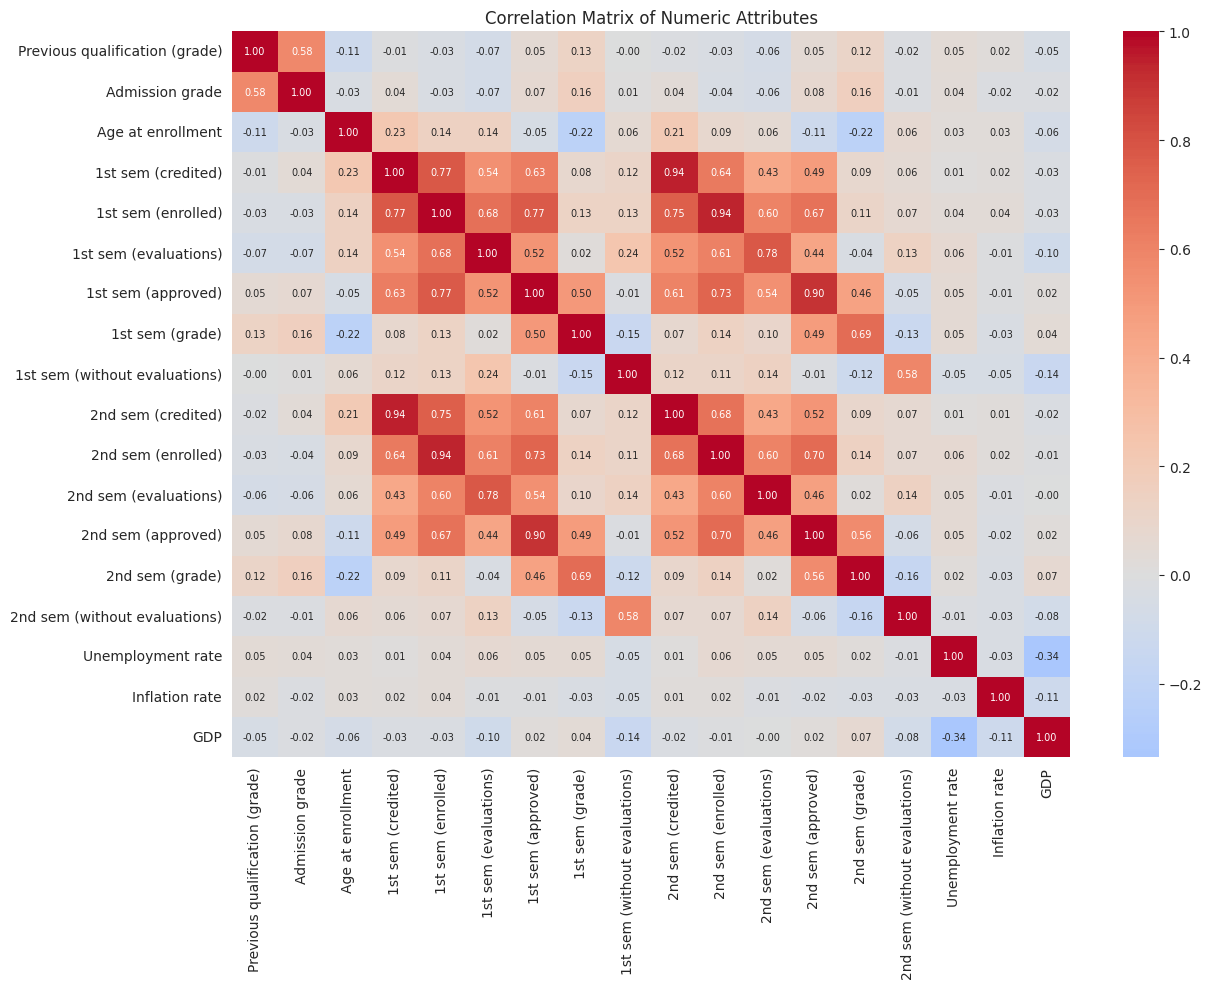

In [20]:
# Heatmap of the correlation matrix, so strongly related pairs stand out visually
# (shorter labels keep the axis readable)
short_names = [c.replace('Curricular units ', '') for c in corr_matrix.columns]

plt.figure(figsize=(13, 10))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            xticklabels=short_names, yticklabels=short_names,
            annot_kws={'size': 7})
plt.title('Correlation Matrix of Numeric Attributes')
plt.tight_layout()
plt.show()

#### **Visualizing the Correlations**

The heatmap shows the correlation between every pair of numeric attributes, with darker red indicating a stronger positive relationship. Three off-diagonal cells stand out clearly: each links a first-semester attribute to its second-semester equivalent for credited, enrolled and approved curricular units, with correlations of 0.90 or above. These are the pairs examined below.

In [21]:
import numpy as np

# Keep only the upper triangle of the matrix so each pair appears once,
# then list the pairs from most to least correlated
corr_pairs = (
    corr_matrix.where(
        np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
    )
    .stack()
    .sort_values(ascending=False)
)

corr_pairs.head(10)

Curricular units 1st sem (credited)     Curricular units 2nd sem (credited)       0.944811
Curricular units 1st sem (enrolled)     Curricular units 2nd sem (enrolled)       0.942627
Curricular units 1st sem (approved)     Curricular units 2nd sem (approved)       0.904002
Curricular units 1st sem (evaluations)  Curricular units 2nd sem (evaluations)    0.778863
Curricular units 1st sem (credited)     Curricular units 1st sem (enrolled)       0.774344
Curricular units 1st sem (enrolled)     Curricular units 1st sem (approved)       0.769083
                                        Curricular units 2nd sem (credited)       0.753747
Curricular units 1st sem (approved)     Curricular units 2nd sem (enrolled)       0.733772
Curricular units 2nd sem (enrolled)     Curricular units 2nd sem (approved)       0.703258
Curricular units 1st sem (grade)        Curricular units 2nd sem (grade)          0.692939
dtype: float64

#### **Ranking the Correlated Pairs**

The upper triangle of the correlation matrix is kept so that each pair of attributes appears only once. The `stack()` function converts the selected values into attribute pairs, while `sort_values()` arranges them from the highest correlation to the lowest. The first ten pairs are then displayed to identify the strongest relationships between the numeric attributes.

In [22]:
# Keep only the pairs whose correlation is at or above the threshold
threshold = 0.85

high_corr_pairs = corr_pairs[corr_pairs >= threshold]

high_corr_pairs

,,0
Curricular units 1st sem (credited),Curricular units 2nd sem (credited),0.944811
Curricular units 1st sem (enrolled),Curricular units 2nd sem (enrolled),0.942627
Curricular units 1st sem (approved),Curricular units 2nd sem (approved),0.904002


#### **Applying the Correlation Threshold**

The correlation threshold is set to 0.85, and the condition `corr_pairs >= threshold` filters the correlation pairs based on this value. This allows us to identify the pairs with the strongest correlations for further feature selection.

A threshold of 0.85 was chosen to restrict removal to attributes that are near-duplicates of each other. A lower threshold would also capture pairs such as `Curricular units 1st sem (enrolled)` and `Curricular units 1st sem (approved)`. These measure different things, since how many courses a student registers for is not the same as how many they pass, so removing either would discard genuine information.


#### **Feature Selection Decision**

Three pairs of numeric attributes showed a correlation above the selected threshold of 0.85. Since the corresponding first- and second-semester attributes measure similar academic aspects, the second-semester attributes from these pairs were selected for removal to reduce redundancy while retaining the corresponding first-semester attributes.

In [23]:
# Store the number of attributes before feature selection

before_feature_selection = df_preprocessed.shape[1]

# Remove highly correlated features

df_preprocessed = df_preprocessed.drop(columns=[
    'Curricular units 2nd sem (credited)',
    'Curricular units 2nd sem (enrolled)',
    'Curricular units 2nd sem (approved)'
])

# Store the number of attributes after feature selection

after_feature_selection = df_preprocessed.shape[1]

print("--- Before Feature Selection ---")
print("Number of attributes:", before_feature_selection)

print("\n--- After Feature Selection ---")
print("Number of attributes:", after_feature_selection)

--- Before Feature Selection ---
Number of attributes: 40

--- After Feature Selection ---
Number of attributes: 37


#### **Result of Feature Selection**

Three highly correlated second-semester attributes were removed based on the correlation threshold of 0.85. The number of attributes was reduced from 40 to 37, reducing redundancy while retaining the corresponding first-semester academic information.

### **2.4 Preprocessing Technique 4: Categorical Encoding**

**Why Categorical Encoding?**

The categorical attributes in the dataset are stored as numerical codes rather than actual numerical measurements. Treating these codes as numerical values may incorrectly imply an order or distance between categories. Therefore, categorical encoding is applied to represent these attributes appropriately for subsequent data mining tasks, particularly clustering.

**Target Attributes:**

- Multi-category attributes: `Marital status`, `Application mode`, `Application order`, `Course`, `Previous qualification`, `Nacionality`, `Mother's qualification`, `Father's qualification`, `Mother's occupation`, `Father's occupation`, and `Age Group` (created in Section 2.1)
- Binary attributes: `Daytime/evening attendance`, `Displaced`, `Educational special needs`, `Debtor`, `Tuition fees up to date`, `Gender`, `Scholarship holder` and `International`

**Technique Applied:** One-Hot Encoding, with the first category of each attribute dropped to avoid redundant columns

In [24]:
# Keep a copy of the data before encoding, so it can be compared afterwards
before_encoding = df_preprocessed.copy()
print("Shape before encoding:", before_encoding.shape)

# Attributes to encode: the category codes, plus the Age Group created in Section 2.1
encoding_cols = categorical_cols + ['Age Group']

# Replace each attribute with one 0/1 column per category
# (drop_first=True removes one category per attribute, since it can be worked out from the others)
df_preprocessed = pd.get_dummies(
    df_preprocessed,
    columns=encoding_cols,
    dtype=int,
    drop_first=True
)

print("Shape after encoding:", df_preprocessed.shape)

Shape before encoding: (4424, 37)
Shape after encoding: (4424, 249)


#### **Applying One-Hot Encoding**

A copy of the dataset is stored in `before_encoding` first, so the data can be compared before and after the transformation.

The `pd.get_dummies()` function replaces each categorical attribute with a set of new columns, one per category, each holding 1 if the student belongs to that category and 0 otherwise. The `columns` parameter lists which attributes to encode, and `dtype=int` makes the new columns hold 0 and 1 rather than True and False.

The `drop_first=True` parameter removes one category from each attribute. That category is not lost: a student with 0 in every remaining column must belong to the dropped one. This also keeps each binary attribute as a single column rather than splitting it into two identical ones.

The dataset grows from 37 to 249 columns.

In [25]:
# Remove the original age column, now represented by the encoded Age Group columns
df_preprocessed = df_preprocessed.drop(columns=['Age at enrollment'])

print("Shape after removing Age at enrollment:", df_preprocessed.shape)

Shape after removing Age at enrollment: (4424, 248)


#### **Removing the Original Age Column**

After encoding, age is represented twice: once as the continuous `Age at enrollment` and once as the encoded `Age Group` columns. Keeping both would count the same information twice in distance-based methods such as K-means, and a decision tree would likely split on the continuous version and ignore the age groups entirely, making the discretization in Section 2.1 pointless.

The original `Age at enrollment` column is therefore removed, leaving 248 columns.

In [26]:
# Before and after for one attribute: Marital status
# Pick one student from each marital status category, in order
examples = before_encoding.groupby('Marital status').head(1).sort_values('Marital status').index

# The encoded columns all start with 'Marital status_'
marital_cols = [c for c in df_preprocessed.columns if c.startswith('Marital status_')]

print("--- Before Encoding ---")
display(before_encoding.loc[examples, ['Marital status']])

print("\n--- After Encoding ---")
display(df_preprocessed.loc[examples, marital_cols])

--- Before Encoding ---


,Marital status
0,1
4,2
166,3
38,4
705,5
919,6



--- After Encoding ---


,Marital status_2,Marital status_3,Marital status_4,Marital status_5,Marital status_6
0,0,0,0,0,0
4,1,0,0,0,0
166,0,1,0,0,0
38,0,0,1,0,0
705,0,0,0,1,0
919,0,0,0,0,1


#### **Before and After Categorical Encoding**

**Before:**
`Marital status` was a single column holding codes from 1 to 6, where 1 represents single, 2 married, 3 widowed, 4 divorced, 5 in a de facto union and 6 legally separated. Stored this way, the codes suggest that a divorced student (4) is numerically closer to a married student (2) than to a single student (1), which has no real meaning.

**After:**
The attribute is replaced by five columns, `Marital status_2` to `Marital status_6`. Each student has a 1 in the column for their category and 0 elsewhere. The single student has 0 in every column, since category 1 was the one dropped. Every category is now the same distance from every other, so no false ordering remains.

#### **Result of Categorical Encoding**
All categorical attributes and `Age Group` were encoded in this way. The number of records remained unchanged at 4,424, while the number of attributes increased from 37 to 248. Binary attributes remained as single columns, and the original `Age at enrollment` column was removed to avoid representing age twice.

### **2.5 Preprocessing Technique 5: Feature Scaling**

**Why Feature Scaling?**

As shown in the exploratory data analysis, the continuous numeric attributes operate on very different scales. Admission grades range from 95 to 190, semester grades from 0 to 20, and the economic indicators fall within much smaller ranges. Distance-based algorithms such as K-means are sensitive to these differences: without scaling, attributes with wider ranges dominate the distance calculations. Decision trees are not affected by scale, so this technique matters mainly for clustering.

**Target Attributes:** Continuous numeric attributes, including `Admission grade`, `Previous qualification (grade)`, `Unemployment rate`, `Inflation rate`, `GDP`, and the remaining first- and second-semester curricular unit attributes

**Technique Applied:** Min-Max Normalization

In [27]:
from sklearn.preprocessing import MinMaxScaler

# Continuous numeric attributes to rescale into the [0, 1] range
# (binary 0/1 columns are already in range, so they are not included)
scale_cols = [
    'Previous qualification (grade)', 'Admission grade',
    'Curricular units 1st sem (credited)', 'Curricular units 1st sem (enrolled)',
    'Curricular units 1st sem (evaluations)', 'Curricular units 1st sem (approved)',
    'Curricular units 1st sem (grade)', 'Curricular units 1st sem (without evaluations)',
    'Curricular units 2nd sem (evaluations)',
    'Curricular units 2nd sem (grade)', 'Curricular units 2nd sem (without evaluations)',
    'Unemployment rate', 'Inflation rate', 'GDP'
]

# Apply Min-Max normalization on a copy of the data
scaler = MinMaxScaler()
df_scaled = df_preprocessed.copy()
df_scaled[scale_cols] = scaler.fit_transform(df_scaled[scale_cols])

# Show a few attributes before and after scaling for comparison
print("--- Before Scaling ---")
display(df_preprocessed[['Admission grade', 'Curricular units 1st sem (grade)', 'Unemployment rate']].head())

print("\n--- After Scaling ---")
display(df_scaled[['Admission grade', 'Curricular units 1st sem (grade)', 'Unemployment rate']].head())

--- Before Scaling ---


,Admission grade,Curricular units 1st sem (grade),Unemployment rate
0,127.3,12.485714,10.8
1,142.5,14.000000,13.9
2,124.8,12.485714,10.8
3,119.6,13.428571,9.4
4,141.5,12.333333,13.9



--- After Scaling ---


,Admission grade,Curricular units 1st sem (grade),Unemployment rate
0,0.340000,0.661495,0.372093
1,0.500000,0.741722,0.732558
2,0.313684,0.661495,0.372093
3,0.258947,0.711447,0.209302
4,0.489474,0.653422,0.732558


#### **Applying Feature Scaling**

The `MinMaxScaler()` from `sklearn.preprocessing` was initialized to transform all continuous numerical attributes into a fixed range between 0 and 1.
The `fit_transform()` method computes the minimum and maximum values for each target column and scales the data accordingly. The `head()` function is used to compare the values before and after scaling to verify that the transformation was correctly applied.
The output confirms that values previously spanning different ranges (e.g., grades between 0 and 200) are now bounded strictly within [0, 1].

In [28]:
# Check minimum and maximum values after scaling
print("Minimum values after scaling:")
print(df_scaled[scale_cols].min())

print("\nMaximum values after scaling:")
print(df_scaled[scale_cols].max())

# Check for missing values after scaling
print("\nMissing values after scaling:")
print(df_scaled[scale_cols].isna().sum())


Minimum values after scaling:
Previous qualification (grade)                    0.0
Admission grade                                   0.0
Curricular units 1st sem (credited)               0.0
Curricular units 1st sem (enrolled)               0.0
Curricular units 1st sem (evaluations)            0.0
Curricular units 1st sem (approved)               0.0
Curricular units 1st sem (grade)                  0.0
Curricular units 1st sem (without evaluations)    0.0
Curricular units 2nd sem (evaluations)            0.0
Curricular units 2nd sem (grade)                  0.0
Curricular units 2nd sem (without evaluations)    0.0
Unemployment rate                                 0.0
Inflation rate                                    0.0
GDP                                               0.0
dtype: float64

Maximum values after scaling:
Previous qualification (grade)                    1.0
Admission grade                                   1.0
Curricular units 1st sem (credited)               1.0
Curric

#### **Checking the Result of Feature Scaling**

After scaling, the transformed dataset was checked using `.min()` and `.max()` across all normalized columns to ensure that all feature values fall strictly within the expected range of 0.0 to 1.0.

Additionally, `.isna().sum()` was called to confirm that the normalization process did not introduce any missing values.
The check confirmed that all target attributes now have a minimum value of 0.0, a maximum value of 1.0, and zero missing values, verifying successful scaling.

#### **Result of Feature Scaling**

All continuous numeric attributes were rescaled into the [0, 1] range using `MinMaxScaler`.

The transformation preserved the shape of each attribute's distribution while removing differences in scale. As a result, each attribute contributes on a comparable scale to distance calculations, which is required for K-means clustering in Phase 3.

### **2.6 Preprocessing Results**

All required data preprocessing techniques were successfully applied in sequence to clean, transform, and standardize the dataset:


1.   **Discretization:** Transformed the right-skewed `Age at enrollment` into structured age brackets to capture non-linear age patterns.
2.   **Handling Missing Values:** Replaced placeholder zero grades, for students who sat no evaluations, with the median grade of assessed students, while retaining missing-value indicators to preserve data integrity.
3.   **Feature Selection:** Removed highly correlated second-semester attributes (r >= 0.85) to reduce redundancy in the dataset.
4.   **Categorical Encoding:** Applied One-Hot Encoding to categorical variables, converting discrete groups into binary indicator features.
5.  **Feature Scaling:** Normalized all continuous numerical attributes to the [0, 1] range using `MinMaxScaler`, ensuring uniform scale across all features.

The final transformed dataset was exported as `Preprocessed_dataset.csv`. Below are the snapshots comparing the raw initial dataset with the final preprocessed output.


In [29]:
# 1. Save the final preprocessed dataframe to a new CSV file
output_filename = 'Preprocessed_dataset.csv'
df_scaled.to_csv(output_filename, index=False)
print(f"Final preprocessed dataset successfully saved as '{output_filename}'")

# 2. Display Snapshots (Original Raw Data vs Final Preprocessed Data)
print("\n--- Snapshot 1: Original Raw Data (First 5 rows) ---")
display(df.head())

print("\n--- Snapshot 2: Final Preprocessed & Scaled Data (First 5 rows) ---")
display(df_scaled.head())


Final preprocessed dataset successfully saved as 'Preprocessed_dataset.csv'

--- Snapshot 1: Original Raw Data (First 5 rows) ---


,Marital status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,Mother's occupation,Father's occupation,Admission grade,Displaced,Educational special needs,Debtor,Tuition fees up to date,Gender,Scholarship holder,Age at enrollment,International,Curricular units 1st sem (credited),Curricular units 1st sem (enrolled),Curricular units 1st sem (evaluations),Curricular units 1st sem (approved),Curricular units 1st sem (grade),Curricular units 1st sem (without evaluations),Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,1,17,5,171,1,1,122.0,1,19,12,5,9,127.3,1,0,0,1,1,0,20,0,0,0,0,0,0.000000,0,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254,1,1,160.0,1,1,3,3,3,142.5,1,0,0,0,1,0,19,0,0,6,6,6,14.000000,0,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070,1,1,122.0,1,37,37,9,9,124.8,1,0,0,0,1,0,19,0,0,6,0,0,0.000000,0,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,17,2,9773,1,1,122.0,1,38,37,5,3,119.6,1,0,0,1,0,0,20,0,0,6,8,6,13.428571,0,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,39,1,8014,0,1,100.0,1,37,38,9,9,141.5,0,0,0,1,0,0,45,0,0,6,9,5,12.333333,0,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate



--- Snapshot 2: Final Preprocessed & Scaled Data (First 5 rows) ---


,Previous qualification (grade),Admission grade,Curricular units 1st sem (credited),Curricular units 1st sem (enrolled),Curricular units 1st sem (evaluations),Curricular units 1st sem (approved),Curricular units 1st sem (grade),Curricular units 1st sem (without evaluations),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target,No evaluations 1st sem,No evaluations 2nd sem,Marital status_2,Marital status_3,Marital status_4,Marital status_5,Marital status_6,Application mode_2,Application mode_5,Application mode_7,Application mode_10,Application mode_15,Application mode_16,Application mode_17,Application mode_18,Application mode_26,Application mode_27,Application mode_39,Application mode_42,Application mode_43,Application mode_44,Application mode_51,Application mode_53,Application mode_57,Application order_1,Application order_2,Application order_3,Application order_4,Application order_5,Application order_6,Application order_9,Course_171,Course_8014,Course_9003,Course_9070,Course_9085,Course_9119,Course_9130,Course_9147,Course_9238,Course_9254,Course_9500,Course_9556,Course_9670,Course_9773,Course_9853,Course_9991,Daytime/evening attendance_1,Previous qualification_2,Previous qualification_3,Previous qualification_4,Previous qualification_5,Previous qualification_6,Previous qualification_9,Previous qualification_10,Previous qualification_12,Previous qualification_14,Previous qualification_15,Previous qualification_19,Previous qualification_38,Previous qualification_39,Previous qualification_40,Previous qualification_42,Previous qualification_43,Nacionality_2,Nacionality_6,Nacionality_11,Nacionality_13,Nacionality_14,Nacionality_17,Nacionality_21,Nacionality_22,Nacionality_24,Nacionality_25,Nacionality_26,Nacionality_32,Nacionality_41,Nacionality_62,Nacionality_100,Nacionality_101,Nacionality_103,Nacionality_105,Nacionality_108,Nacionality_109,Mother's qualification_2,Mother's qualification_3,Mother's qualification_4,Mother's qualification_5,Mother's qualification_6,Mother's qualification_9,Mother's qualification_10,Mother's qualification_11,Mother's qualification_12,Mother's qualification_14,Mother's qualification_18,Mother's qualification_19,Mother's qualification_22,Mother's qualification_26,Mother's qualification_27,Mother's qualification_29,Mother's qualification_30,Mother's qualification_34,Mother's qualification_35,Mother's qualification_36,Mother's qualification_37,Mother's qualification_38,Mother's qualification_39,Mother's qualification_40,Mother's qualification_41,Mother's qualification_42,Mother's qualification_43,Mother's qualification_44,Father's qualification_2,Father's qualification_3,Father's qualification_4,Father's qualification_5,Father's qualification_6,Father's qualification_9,Father's qualification_10,Father's qualification_11,Father's qualification_12,Father's qualification_13,Father's qualification_14,Father's qualification_18,Father's qualification_19,Father's qualification_20,Father's qualification_22,Father's qualification_25,Father's qualification_26,Father's qualification_27,Father's qualification_29,Father's qualification_30,Father's qualification_31,Father's qualification_33,Father's qualification_34,Father's qualification_35,Father's qualification_36,Father's qualification_37,Father's qualification_38,Father's qualification_39,Father's qualification_40,Father's qualification_41,Father's qualification_42,Father's qualification_43,Father's qualification_44,Mother's occupation_1,Mother's occupation_2,Mother's occupation_3,Mother's occupation_4,Mother's occupation_5,Mother's occupation_6,Mother's occupation_7,Mother's occupation_8,Mother's occupation_9,Mother's occupation_10,Mother's occupation_90,Mother's occupation_99,Mother's occupation_122,Mother's occupation_123,Mother's occupation_125,Mother's occupation_131,Mother's occupation_132,Mother's occupation_134,Mother's occupation_141,Mother's oc

#### **Exporting and Verifying the Preprocessed Dataset**

This code saves the final preprocessed DataFrame (`df_scaled`) into a new CSV file named `Preprocessed_dataset.csv` using `to_csv()`, ensuring the original raw dataset remains untouched.
To verify the overall dataset transformation, two snapshots are displayed:

 * Snapshot 1: Displays the first 5 rows of the original raw dataset.

 * Snapshot 2: Displays the first 5 rows of the fully preprocessed and scaled dataset.

Comparing both snapshots confirms that missing values were handled, categorical features were encoded, unnecessary attributes were dropped, and all continuous features were successfully rescaled into the [0, 1] range.